<a href="https://colab.research.google.com/github/lutfianaade/customer-churn-pdm/blob/main/Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA COLLECTION**

mengambil dataset dari kaggle https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

**LOAD DATA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




In [2]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**DATA UNDERSTANDING**

In [3]:
#kalo ini buat liat tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#buat cek data kosong yachh
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.nunique()

#buat tau jumlah kategori tiap kolom

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


**EXPLORATORY DATA ANALYSIS**

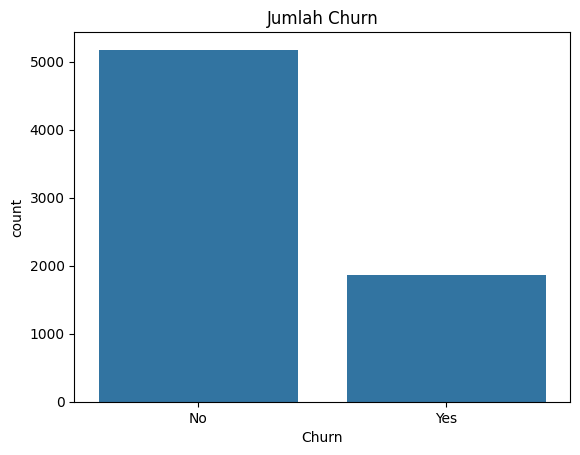

In [9]:
#countplot buat ngitung jumlah
sns.countplot(x='Churn', data=df)
plt.title('Jumlah Churn')
plt.show()

#insight sebagian besar pelanggan tidak churn, tetepai jg terdapat jumlah churn yg signifikan

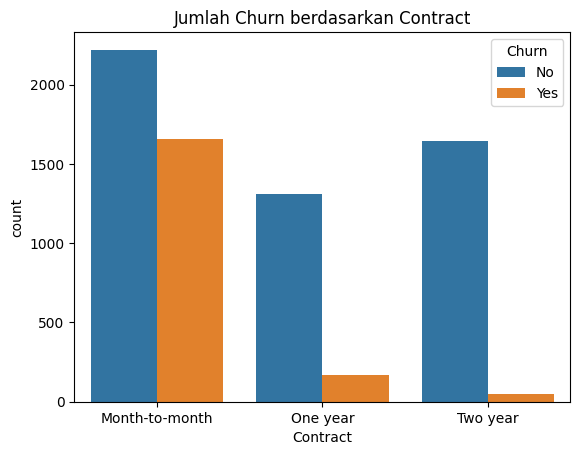

In [10]:
#buat bandingin tiap jenis kolom
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Jumlah Churn berdasarkan Contract')
plt.show()

#insightnya pelanggan yg cotractnya month to month lebih banyak churnya dibanding yg kontraknya
#jangka panjang. hal ini menunjukkan bahwa pelanggan tanpa kontrak yg panjang lebih mudah pindah layanan.

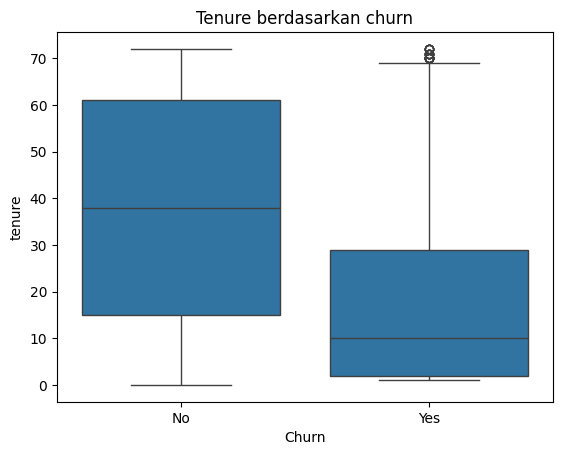

In [11]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure berdasarkan churn')
plt.show()

#insighntya adalah pelanggan yg churn itu malah punya tenure (pelanggan baru )yg lebih rendah drpd pelanggan yg tidak churn

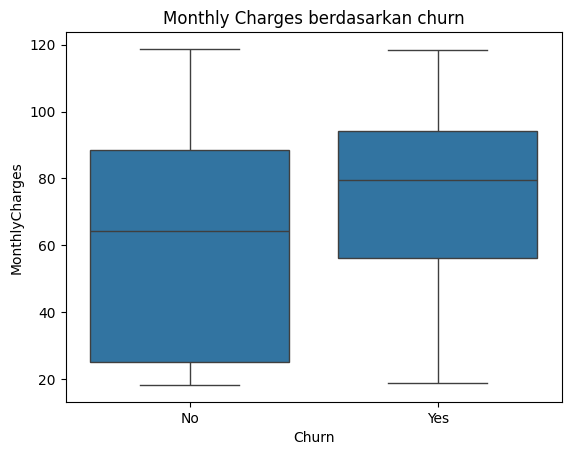

In [12]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges berdasarkan churn')
plt.show()

#insighntya adlh pelanggan dg biaya bulanan lebih tinggi itu cenderung lebih bnayak churn

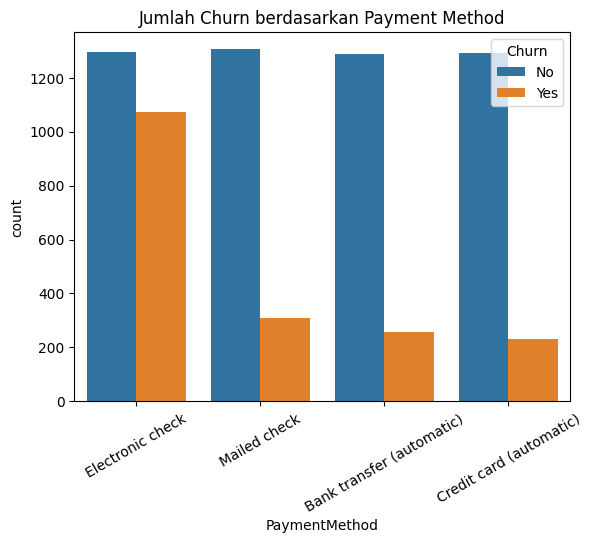

In [13]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Jumlah Churn berdasarkan Payment Method')
plt.xticks(rotation=30)
plt.show()


**DATA PREPROCESSING**

In [21]:
#mendeteksi outlier
Q1 = df['tenure'].quantile(0.25)
Q3 = df['tenure'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier = df[(df['tenure'] < lower) | (df['tenure'] > upper)]
print("Jumlah outlier:", len(outlier))

Jumlah outlier: 0


In [22]:
#buat mengubah tipe data, karna sblmnya total biaya itu harusnya float bukan string, sehingga kita harus mengubahnya
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [23]:
df = df.dropna()

In [24]:
#menghapus kolom customer id karena tidak dibtuuhkan/ tidak berpengaruh thd churn
df = df.drop('customerID', axis=1)

In [25]:
#encoding
df = pd.get_dummies(df, drop_first=True)

In [26]:
#memisahkan fitur dan target
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [27]:
#memastikan target numerik
y = y.astype(int)

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Sebelum SMOTE:")
print(y.value_counts())

print("Setelah SMOTE:")
print(y_res.value_counts())


Sebelum SMOTE:
Churn_Yes
0    5163
1    1869
Name: count, dtype: int64
Setelah SMOTE:
Churn_Yes
0    5163
1    5163
Name: count, dtype: int64


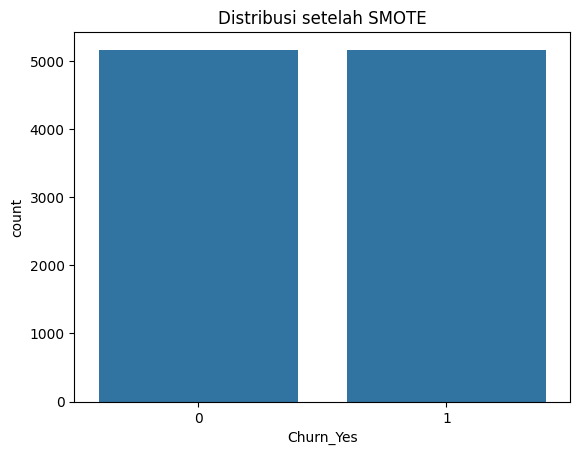

In [29]:
sns.countplot(x=pd.Series(y_res))
plt.title("Distribusi setelah SMOTE")
plt.show()

**DATASET TRACKING**

In [30]:
df_track = pd.read_csv('/content/Telco-Customer-Churn.csv')

print("Data awal:", df_track.shape)

df_track['TotalCharges'] = pd.to_numeric(df_track['TotalCharges'], errors='coerce')

df_track = df_track.dropna()
print("Setelah cleaning:", df_track.shape)

df_track = df_track.drop('customerID', axis=1)

df_track = pd.get_dummies(df_track, drop_first=True)
print("Setelah encoding:", df_track.shape)


Data awal: (7043, 21)
Setelah cleaning: (7032, 21)
Setelah encoding: (7032, 31)
